# 03 · De un estimador a su incertidumbre

**RA1–RA2.** Distinguir dispersión, error estándar e intervalo; planificar precisión y comprobar cobertura. Una sesión y práctica autónoma.

**Caso:** ComercioSur, datos simulados. Ejecutar en orden con kernel activo. Cada ejercicio exige una interpretación y un límite; consultar [manual](../material_propio/EBA_manual_cientifico.html) y [guía](../guia_maestra_eba.html). El curso presupone manejo elemental de tablas de Fundamentos. No instalar paquetes desde las celdas.

### Antes de ejecutar

Núcleo · 60–90 min orientativos.

**Objetivo:** Elegir un intervalo según el parámetro, la población y el diseño.

**Preparación:** Muestreo y distribuciones de los módulos 01–02.

**Ejemplo de referencia:** Contrastar un IC t para tiempo medio con Wilson para proporción de pedidos resueltos.

**Práctica:** Cambiar confianza y n; separar variabilidad de pedidos de incertidumbre sobre la media.

**Criterio de logro:** Reportar estimación, intervalo, unidad, población objetivo y condiciones de validez.

[Guía y secuencia](../guia_maestra_eba.html#ruta-aprendizaje) · [Fundamento del manual](../material_propio/EBA_manual_cientifico.html#sec-intervalos)

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import ipywidgets as widgets
from IPython.display import display, Markdown
RAIZ=next(p for p in (Path.cwd(),*Path.cwd().parents) if (p/'_transversal/datos').is_dir())
sys.path.insert(0,str(RAIZ/'02_Estadistica_Business_Analytics/reproducibilidad'))
from eba_recursos import *
df=pedidos()
plt.rcParams.update({'figure.figsize':(7,3.4),'axes.spines.top':False,'axes.spines.right':False})


<a id="estimacion"></a>
## Media e intervalo t

Población objetivo aquí: pedidos futuros de un proceso estable. El intervalo t usa s/√n y supone independencia; exacto para datos normales y aproximado para una media con suficiente n. No usar corrección finita para esta superpoblación.

In [2]:
display(pd.Series(ic_media(df.tiempo_min))); print('Media del marco finito (objetivo distinto):',poblacion().tiempo_min.mean())

n        600.000000
media     36.256283
sd         7.828359
se         0.319591
li        35.628627
ls        36.883939
dtype: float64

Media del marco finito (objetivo distinto): 36.247298


<a id="proporciones"></a>
## Intervalo de Wilson

Wilson permanece dentro de [0,1] y evita intervalos degenerados con cero éxitos. Es aproximado binomial; use datos independientes con probabilidad común. Reporte numerador y denominador.

In [3]:
k=int(df.resuelto.sum()); n=len(df);print(k,n,k/n,wilson(k,n)); display(pd.DataFrame([{'k':k,'n':20,'li':wilson(k,20)[0],'ls':wilson(k,20)[1]} for k in [0,1,10,19,20]]))

453 600 0.755 (np.float64(0.7190355577019193), np.float64(0.7877199747810933))


,k,n,li,ls
0,0,20,0.000000,0.161125
1,1,20,0.008881,0.236131
2,10,20,0.299298,0.700702
3,19,20,0.763869,0.991119
4,20,20,0.838875,1.000000


<a id="bootstrap"></a>
## Bootstrap de una media asimétrica

Remuestrear filas independientes, con reemplazo, representa la distribución empírica; no crea información. El intervalo percentil es una aproximación, no corrige selección ni dependencia. Para clientes repetidos sería necesario remuestrear clientes.

IC percentil 95%: [49.36285208 52.4972975 ]
IC t: {'n': 600, 'media': np.float64(50.913016666666664), 'sd': np.float64(19.42343264270673), 'se': np.float64(0.7929583171325015), 'li': np.float64(49.355700255580764), 'ls': np.float64(52.470333077752564)}


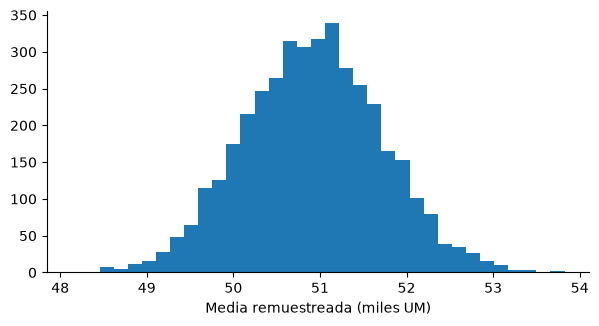

In [4]:
rng=np.random.default_rng(SEMILLA);x=df.ticket_mil.to_numpy();boot=rng.choice(x,(4000,len(x)),replace=True).mean(axis=1);print('IC percentil 95%:',np.quantile(boot,[.025,.975]));print('IC t:',ic_media(x));plt.hist(boot,bins=35);plt.xlabel('Media remuestreada (miles UM)');plt.show()

<a id="cobertura"></a>
## Qué significa 95%

En repeticiones del procedimiento, cerca del 95% de intervalos cubre el parámetro fijo bajo el modelo. No significa que 95% de pedidos esté en el intervalo de la media. Actividad: contraste n=10 y n=100, confianza 90% y 99%.

In [5]:
@widgets.interact(n=widgets.IntSlider(value=40,min=10,max=100,step=10),nivel=widgets.Dropdown(options=[.9,.95,.99],value=.95))
def cobertura(n,nivel):
    rng=np.random.default_rng(SEMILLA);x=rng.normal(40,7,(1000,n));med=x.mean(axis=1);se=x.std(axis=1,ddof=1)/np.sqrt(n);d=stats.t.ppf((1+nivel)/2,n-1)*se;ok=(med-d<=40)&(40<=med+d);print(f'Cobertura {ok.mean():.3f}; error Monte Carlo aprox. {np.sqrt(nivel*(1-nivel)/1000):.3f}; ancho medio {2*d.mean():.2f} min')
    plt.errorbar(np.arange(40),med[:40],yerr=d[:40],fmt='o',capsize=2);plt.axhline(40,color='red');plt.xlabel('Repetición');plt.ylabel('Media e IC (min)');plt.show()

interactive(children=(IntSlider(value=40, description='n', min=10, step=10), Dropdown(description='nivel', ind…

<a id="precision"></a>
## Precisión no implica representatividad

Compare IC t de una muestra solo Web con el de todos los pedidos. El primero se refiere a Web; la diferencia de anchura no autoriza generalizar. Actividad: formule una conclusión correcta para cada población y explique si una anchura de 1 minuto basta para decidir.

In [6]:
display(pd.DataFrame([{'poblacion':'Todos',**ic_media(df.tiempo_min)},{'poblacion':'Web',**ic_media(df.query("canal=='Web'").tiempo_min)}]))

,poblacion,n,media,sd,se,li,ls
0,Todos,600,36.256283,7.828359,0.319591,35.628627,36.883939
1,Web,383,37.562689,7.298146,0.372918,36.829461,38.295918


## Comprobación y entrega

Responda la autoevaluación y complete la actividad del último bloque. Entregue objetivo, método, supuesto, resultado con unidades y decisión condicionada. Las soluciones orientadoras permiten estudiar, pero no sustituyen su interpretación.

In [7]:
auto_03=pregunta('¿El IC de la media contiene el 95% de los pedidos individuales?','Sí, mide la dispersión de pedidos','No, mide incertidumbre sobre la media','Un intervalo de predicción individual tiene otra finalidad y suele ser más ancho.')
display(auto_03)